<a href="https://colab.research.google.com/github/Sikaaaa3/Lab-3/blob/main/lab_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name : Janet Dankwah Nortey
Student ID: 23112028


In [2]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


Section 1 — Inside a Neural Network: From One Neuron to Gradient Descent

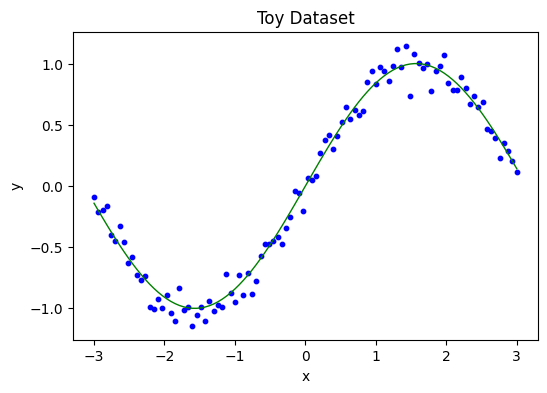

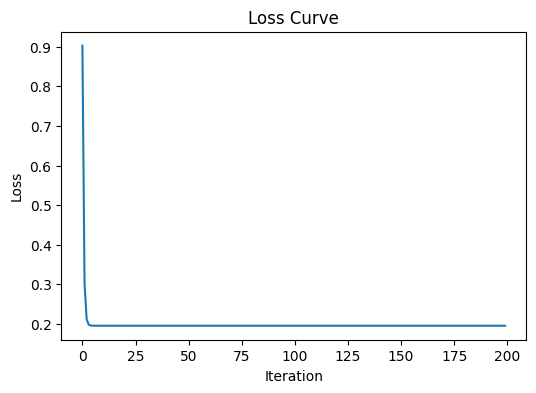

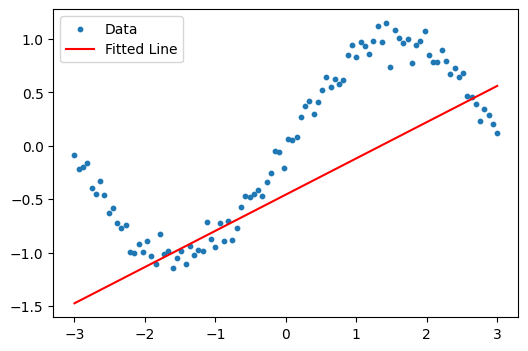

In [3]:
#Generate toy data
x = np.linspace(-3, 3, 100)
noise =np.random.normal(0,0.1,len(x))
y=np.sin(x) + noise

plt.figure(figsize=(6,4))
plt.scatter(x,y, s = 10, color="blue")
plt.plot(x, np.sin(x), color = "green", lw = 1, label = "true sin(x)")
plt. title("Toy Dataset")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

#Initialize parameters
w=np.random.randn() * 0.1
b=np.random.randn() *0.1

lr = 0.1
losses =[]

#Gradient Descent
for i in range(200):

  #Prediction
  y_hat = w * x

  #compute MSE loss
  loss = np.mean((y_hat - y) ** 2)
  losses.append(loss)

  #compute gradients
  dw=np.mean(2 * (y_hat - y) * x)
  db=np.mean(2 * (y_hat -y))

  #update parameters
  w-= lr * dw
  b-= lr * db

#Plot loss
plt.figure(figsize=(6,4))
plt.plot(losses)
plt.title("Loss Curve")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show

#Plot fitted line
plt.figure(figsize=(6,4))
plt.scatter(x,y, s = 10, label="Data")
plt.plot(x,w * x+b, color = "red", label = "Fitted Line")
plt.legend()
plt.show()




Derive the dloss/dw by hand then post the picture here

**Part** 1.2 — Hidden layers and activations: why depth helps

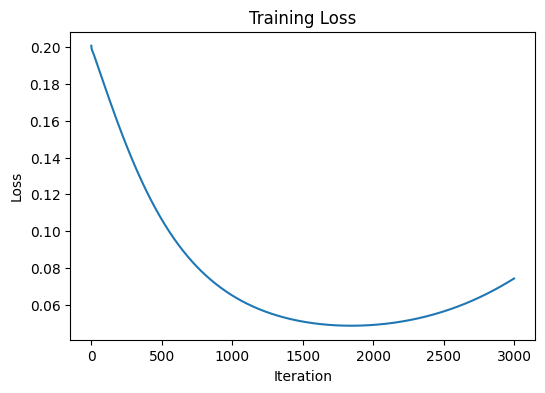

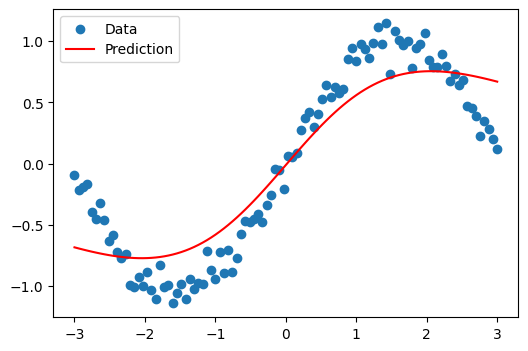

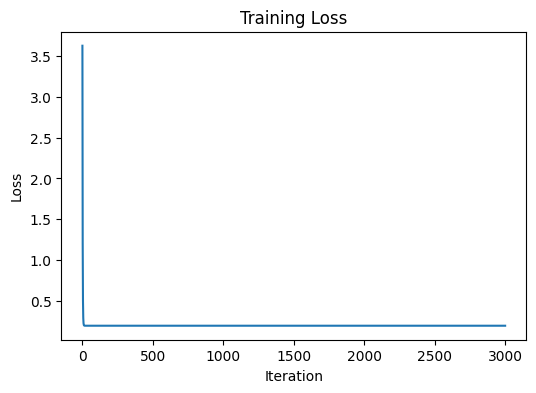

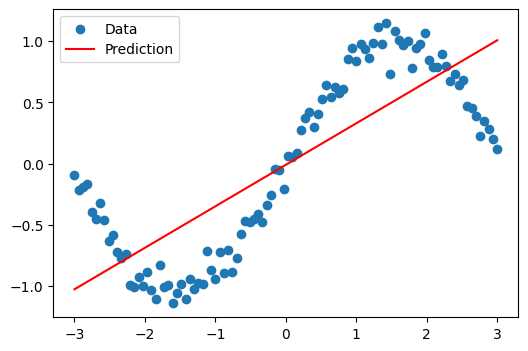

In [4]:
# Initialise parameter
x= x.reshape(-1,1)
y=y.reshape(-1,1)

W1 = np.random.randn(1, 8) * 0.5
b1 = np.zeros(8)

W2 = np.random.randn(8, 1) * 0.5
b2 = np.zeros(1)

lr = 0.01
losses = []

#Forward Pass
for i in range(3000):
      z1 = x @ W1 + b1
      h = np.tanh(z1)
      y_hat = h @ W2 + b2

      loss = np.mean((y_hat - y) ** 2)
      losses.append(loss)

      # Backwards Pass
      d_yhat = 2 * (y_hat - y) / len(y)

      dW2 = h.T @ d_yhat
      db2 = d_yhat.sum(axis=0)

      dh = d_yhat @ W2.T

      dz1 = dh
      dW1 = x.T @ dz1
      db1 = dz1.sum(axis=0)

      #Update the Parameters
      W1 -= lr * dW1
      b1 -= lr * db1

      W2 -= lr * dW2
      b2 -= lr * db2

#Plot the loss
plt.figure(figsize=(6,4))
plt.plot(losses)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

# Plot the final prediction
plt.figure(figsize=(6,4))
plt.scatter(x, y, label="Data")
plt.plot(x, y_hat, color="red", label="Prediction")
plt.legend()
plt.show()



#Re- Run with tanh

x= x.reshape(-1,1)
y=y.reshape(-1,1)

W1 = np.random.randn(1, 8) * 0.5
b1 = np.zeros(8)

W2 = np.random.randn(8, 1) * 0.5
b2 = np.zeros(1)

lr = 0.01
losses = []
#Forward Pass
for i in range(3000):
      z1 = x @ W1 + b1
      h = z1
      y_hat = h @ W2 + b2

      loss = np.mean((y_hat - y) ** 2)
      losses.append(loss)

      # Backwards Pass
      d_yhat = 2 * (y_hat - y) / len(y)

      dW2 = h.T @ d_yhat
      db2 = d_yhat.sum(axis=0)

      dh = d_yhat @ W2.T

      dz1 = dh

      dW1 = x.T @ dz1
      db1 = dz1.sum(axis=0)

      #Update the Parameters
      W1 -= lr * dW1
      b1 -= lr * db1

      W2 -= lr * dW2
      b2 -= lr * db2

#Plot the loss
plt.figure(figsize=(6,4))
plt.plot(losses)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

# Plot the final prediction
plt.figure(figsize=(6,4))
plt.scatter(x, y, label="Data")
plt.plot(x, y_hat, color="red", label="Prediction")
plt.legend()
plt.show()













You have to something here

Part 1.3 — The learning rate: too cold, too hot, just right


/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:127: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/tmp/ipykernel_6489/704468285.py:18: RuntimeWarning: overflow encountered in square
  loss = np.mean((y_hat - y) ** 2)
/tmp/ipykernel_6489/704468285.py:25: RuntimeWarning: overflow encountered in matmul
  dh = d_yhat @ w2.T
/tmp/ipykernel_6489/704468285.py:26: RuntimeWarning: invalid value encountered in multiply
  dz1 = dh * (1 - np.tanh(z1) ** 2)
/usr/local/lib/python3.12/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


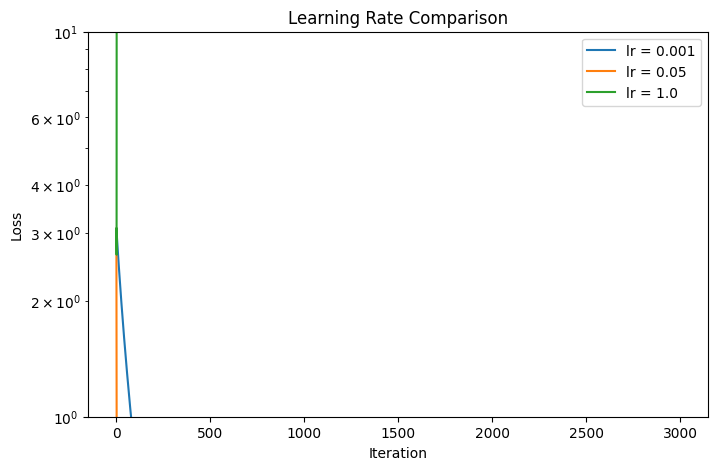

In [5]:
def train_toy(lr, steps=3000):
  np.random.seed(42)

  w1 = np.random.randn(1, 8) * 0.5
  b1 = np.zeros(8)

  w2 = np.random.randn(8, 1) * 0.5
  b2 = np.zeros(1)

  losses =[]

  for i in range(steps):
    #Forward pass
    z1 = x @ w1 + b1
    h = np.tanh(z1)
    y_hat = h @ w2 + b2

    loss = np.mean((y_hat - y) ** 2)
    losses.append(loss)

    #Backward pass
    d_yhat = 2 * (y_hat - y) / len(y)
    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)
    dh = d_yhat @ w2.T
    dz1 = dh * (1 - np.tanh(z1) ** 2)
    dW1 = x.T @ dz1
    db1 = dz1.sum(axis=0)

    #update
    w1 -= lr * dW1
    b1 -= lr * db1

    w2 -= lr * dW2
    b2 -= lr * db2

  return losses

#Training with the three learning rates
loss1 = train_toy(0.001)
loss2 = train_toy(0.05)
loss3 = train_toy(1.0)


#Plot of the three graph
plt.figure(figsize=(8,5))

plt.plot(loss1, label="lr = 0.001")
plt.plot(loss2, label="lr = 0.05")
plt.plot(loss3, label="lr = 1.0")

plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Learning Rate Comparison")
plt.legend()

plt.show()








You have to do student Reasoning

Section 2 — A Real Feedforward Network in PyTorch

Part 2.1 — Preprocess and split (recycled from Lab 2)


In [24]:
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"

#Load dataset
df = pd.read_csv(OBESITY_URL)

df.head()

# seperating features from the target
x= df.drop("NObeyesdad", axis =1)
y=df["NObeyesdad"]

#One hot encoding on the categorical features
x=pd.get_dummies(x, dtype = int)

#Label encode the target
from sklearn.preprocessing import LabelEncoder
label_encoder =LabelEncoder()
y=label_encoder.fit_transform(y)


from sklearn.model_selection import train_test_split

#first split
X_train, X_temp, y_train, y_temp = train_test_split(
    x,
    y,
    test_size=0.40,
    stratify=y,
    random_state=RANDOM_STATE
)

#Split into validation and test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=RANDOM_STATE
)

# checking output
print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

# standardizing the features

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

x_train = scaler.fit_transform(X_train)

X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

#Convert boolean columns to float
X_train = X_train.astype(float)
X_val = X_val.astype(float)
X_test = X_test.astype(float)

#converting to tensors

X_train = torch.tensor(X_train.to_numpy(), dtype=torch.float32)

X_val = torch.tensor(X_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_val = torch.tensor(y_val, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)


# TODO 6A: Create TensorDatasets
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

#create dataloader
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)










Training: (1266, 31)
Validation: (422, 31)
Test: (423, 31)


Student Reasoning